In [1]:
from core.training import train_tdse_example
import matplotlib.pyplot as plt
import torch
from schrodinger_box.time_dependent_1d import ansatzfactor_HO_asym,ansatzfactor_HO_sym,PotentialHarmonicOscillator,ansatzfactor_1Dbox, ansatzfactor_nothing
import math

L = 1.0
T = 5.0

In [ ]:
n = 2
E = ((math.pi**2)*(n**2))/(2*(2*L)**2)

def initial_condition(x): 
    if n % 2 == 1:    
        return math.sqrt(1/L)*torch.cos(((n*math.pi)/(2*L))*x)
    else: 
        return math.sqrt(1/L)*torch.sin(((n*math.pi)/(2*L))*x)
    
def analytic(x,t): 
    return initial_condition(x)*torch.exp(-torch.complex(torch.tensor([0.0]),torch.tensor([1.0]))*E*t)

torch.manual_seed(124)

ansatz_factor = ansatzfactor_1Dbox

N_x_samples = 256     # 2048
N_t_samples = 100   # 50

x_vals = torch.linspace(-L,L,N_x_samples)
t_vals = torch.linspace(0,T,N_t_samples)

pinn,loss_vals = train_tdse_example(
    L = L, 
    T = T,
    n_epochs = 2000,
    N_x_samples = N_x_samples,
    N_t_samples = N_t_samples,
    width = 30,
    hidden_layers = 4,
    lr = 1e-2,
    ansatz_factor = ansatz_factor,
        #potential = PotentialHarmonicOscillator(),
    initial_condition = initial_condition,
    batch_size = 1024    # 1024
)


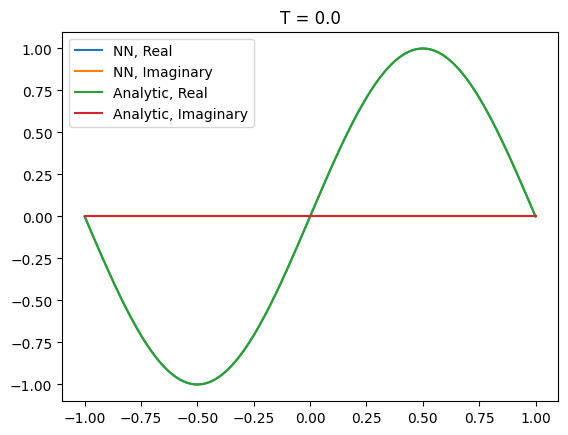

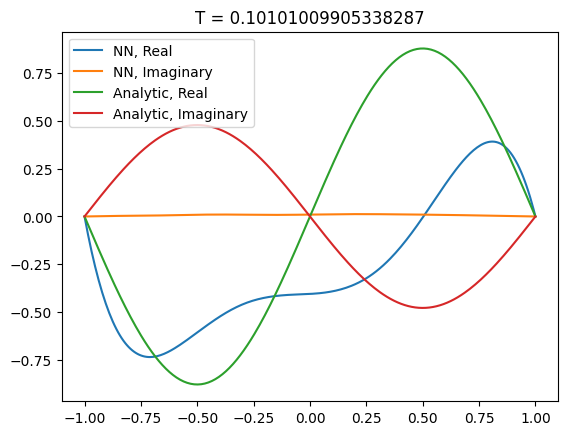

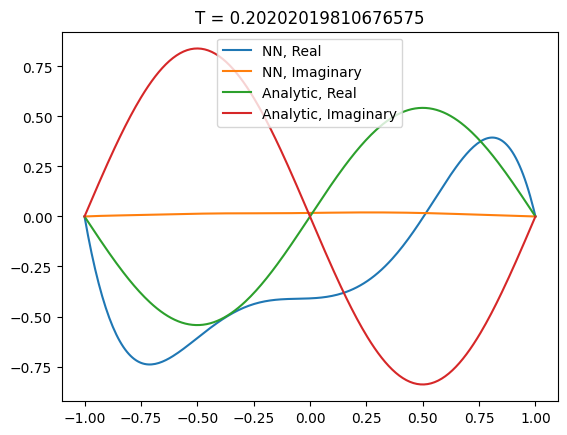

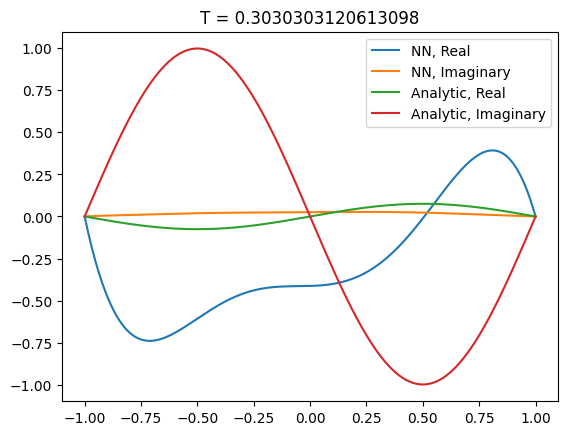

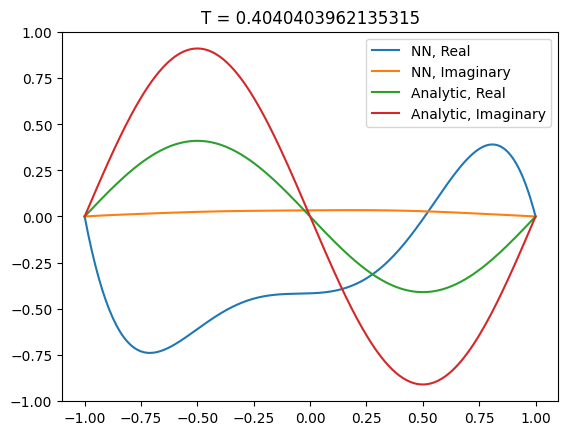

In [ ]:
def analytic(x,t): 
    return initial_condition(x)*torch.exp(-torch.complex(torch.tensor([0.0]),torch.tensor([1.0]))*E*t)

input = torch.zeros(N_x_samples*N_t_samples,2)

x,t = torch.meshgrid(torch.linspace(-L,L,N_x_samples),torch.linspace(0,T,N_t_samples),indexing="ij")

input[:,0] = torch.flatten(x.T)
input[:,1] = torch.flatten(t.T)

NN_psi = pinn(input).detach()

x_test = torch.linspace(-L,L,N_x_samples)

for i in range(0,10,2): 
    plt.title(f"T = {t_vals[i]}")
    plt.plot(x_test,NN_psi[i*N_x_samples:(i+1)*N_x_samples].real,label="NN, Real")
    plt.plot(x_test,NN_psi[i*N_x_samples:(i+1)*N_x_samples].imag,label="NN, Imaginary")
    plt.plot(x_test,analytic(x_test,t_vals[i]).real,label="Analytic, Real")
    plt.plot(x_test,analytic(x_test,t_vals[i]).imag,label="Analytic, Imaginary")
    plt.legend()
    plt.show()